In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
auev=27.2114
cau=137.036
nnm=18.8973


In [2]:
########### PART I ###########

In [3]:
#Simplest 1st orded integration method (too many points are needed)

def TLS_int(detuning,OmR,gammafree,rhoeg0,rhoee0,wtmax,nsteps):
    rhoeg=[rhoeg0]
    rhoee=[rhoee0]
    wttab=np.linspace(0,wtmax,nsteps)
    dwt=wttab[1]-wttab[0]
    for i in range(nsteps-1):
        rhoeg.append(rhoeg[i]+dwt*(-(1j*(1-detuning)+gammafree/2)*rhoeg[i]+1j*OmR*np.exp(-1j*wttab[i])*(2*rhoee[i]-1)))
        rhoee.append(rhoee[i]+dwt*(-gammafree*rhoee[i]+1j*OmR*(rhoeg[i]*np.exp(1j*wttab[i])-np.conjugate(rhoeg[i])*np.exp(-1j*wttab[i]))))
    return wttab,rhoeg,rhoee


#Definition of the functions for RK45 integration
def fTLS(t,y,detuning,OmR,gammafree):
    rhoegt,rhoeet=y
    drhoegt=-(1j*(1-detuning)+gammafree/2)*rhoegt+1j*OmR*np.exp(-1j*t)*(2*rhoeet-1)
    drhoeet=-gammafree*rhoeet+1j*OmR*(rhoegt*np.exp(1j*t)-np.conjugate(rhoegt)*np.exp(-1j*t))
    return [drhoegt,drhoeet]




In [4]:
#1st order method

gammafree=0.0001
OmR=0.1
detuning=0
rhoeg0=0
rhoee0=0
wtmax=100
nsteps=200000
wttab,rhoeg,rhoee=TLS_int(detuning,OmR,gammafree,rhoeg0,rhoee0,wtmax,nsteps)

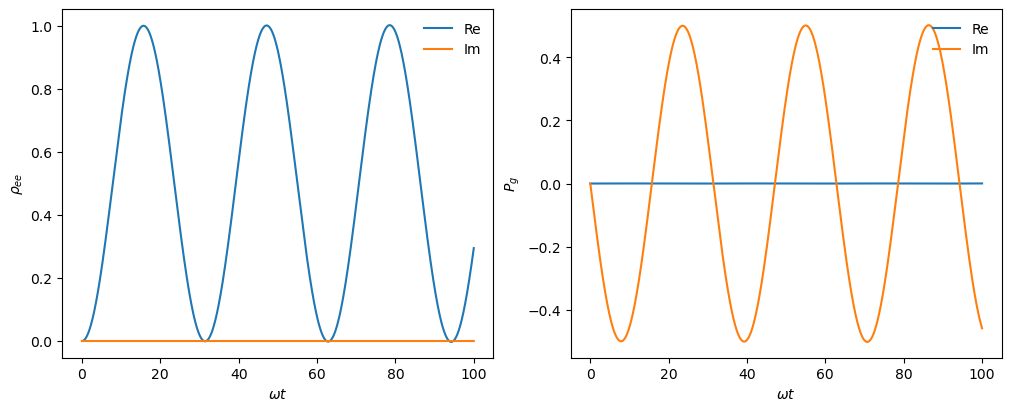

In [5]:
fig, axes = plt.subplots(1,2, constrained_layout=True,figsize=(10, 4))

axes[0].set_xlabel(r'$\omega t$')
axes[0].set_ylabel(r'$\rho_{ee}$')

axes[0].plot(wttab,np.real(rhoee),label=r'Re')
axes[0].plot(wttab,np.imag(rhoee),label=r'Im')
axes[0].legend(loc='upper right',fontsize=10,frameon=False)

axes[1].set_xlabel(r'$\omega t$')
axes[1].set_ylabel(r'$P_g$')
axes[1].plot(wttab,np.real(np.exp(1j*wttab)*rhoeg),label=r'Re')
axes[1].plot(wttab,np.imag(np.exp(1j*wttab)*rhoeg),label=r'Im')
axes[1].legend(loc='upper right',fontsize=10,frameon=False)

In [6]:
#RK45 method

gammafree=0.1
OmR=1
detuning=0.1
rhoeg0=0
rhoee0=0
wtmax=200
nsteps=2000
wt_span=(0,wtmax)
wt_eval=np.linspace(0,wtmax,nsteps)
rho0=[rhoeg0+0j,rhoee0+0j] #solve_ivp interprets the function as complex only if it has complex initial conditions

sol = solve_ivp(fTLS,wt_span,rho0,method='RK45',args=(detuning,OmR,gammafree),t_eval=wt_eval)

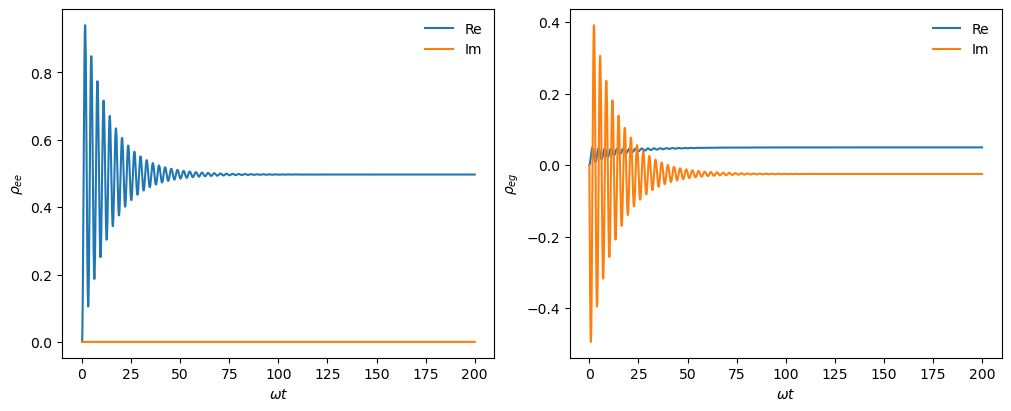

In [7]:
fig, axes = plt.subplots(1,2, constrained_layout=True,figsize=(10, 4))

axes[0].set_xlabel(r'$\omega t$')
axes[0].set_ylabel(r'$\rho_{ee}$')

axes[0].plot(wt_eval,np.real(sol.y[1]),label=r'Re')
axes[0].plot(wt_eval,np.imag(sol.y[1]),label=r'Im')
axes[0].legend(loc='upper right',fontsize=10,frameon=False)

axes[1].set_xlabel(r'$\omega t$')
axes[1].set_ylabel(r'$\rho_{eg}$')
axes[1].plot(wt_eval,np.real(np.exp(1j*wt_eval)*sol.y[0]),label=r'Re')
axes[1].plot(wt_eval,np.imag(np.exp(1j*wt_eval)*sol.y[0]),label=r'Im')
axes[1].legend(loc='upper right',fontsize=10,frameon=False)

In [8]:
#Calculating steady-state solution as a function of the detuning

gammafree=0.5
OmR=0.1
rhoeg0=0
rhoee0=0
wtmax=200
nsteps=2000
wt_span=(0,wtmax)
wt_eval=np.linspace(0,wtmax,nsteps)
rho0=[rhoeg0+0j,rhoee0+0j] 

detuning_tab=np.linspace(-10,10,1000)
rhoeg_steady=[]
for detuning in detuning_tab: 
    sol = solve_ivp(fTLS,wt_span,rho0,method='RK45',args=(detuning,OmR,gammafree),t_eval=wt_eval)
    rhoeg_steady.append(np.exp(1j*wt_span[-1])*sol.y[0][-1])

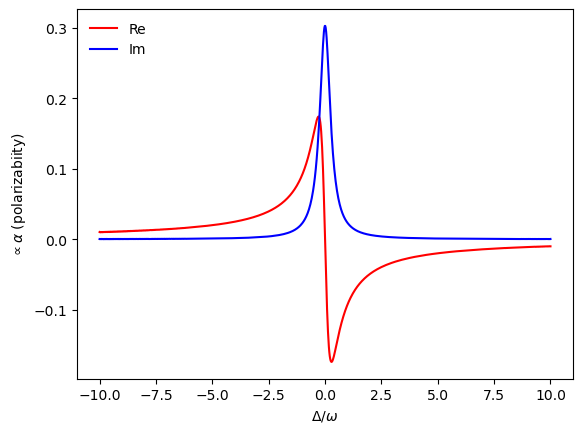

In [9]:
plt.xlabel(r'$\Delta/\omega$')
plt.ylabel(r'$\propto \alpha $ (polarizabiity)')
plt.plot(detuning_tab,-np.real(rhoeg_steady),color='red',label=r'Re')
plt.plot(detuning_tab,-np.imag(rhoeg_steady),color='blue',label=r'Im')
plt.legend(loc='upper left',fontsize=10,frameon=False)

In [10]:
############# PART II ##############

In [11]:
def fThLS(t,y,detuning,wei,OmP,OmC,gammafree):
    rhoegt,rhoeet,rhoggt,rhoeit,rhoigt=y
    weg=1-detuning
    drhoegt = -(1j*weg+gammafree/2)*rhoegt+1j*OmP*np.exp(-1j*t)*(rhoeet-rhoggt)-1j*OmC*rhoigt*np.exp(-1j*wei*t)
    drhoeit = -(1j*wei+gammafree/2)*rhoeit+1j*OmC*(2*rhoeet+rhoggt-1)*np.exp(-1j*wei* t)- 1j*OmP*np.conj(rhoigt)*np.exp(-1j*t)
    drhoigt = -1j*(weg-wei)*rhoigt+1j*OmP*np.exp(-1j*t)*np.conj(rhoeit)-1j*OmC*np.exp(1j*wei*t)*rhoegt
    drhoeet = -gammafree*rhoeet+1j*OmP*(rhoegt*np.exp(1j*t)-np.conj(rhoegt)*np.exp(-1j*t))+1j*OmC*(rhoeit*np.exp(1j*wei*t)-np.conj(rhoeit)*np.exp(-1j*wei*t))
    drhoggt = 2*OmP*np.imag(np.exp(1j*t)*rhoegt)+gammafree*rhoeet
    
    return [drhoegt,drhoeet,drhoggt,drhoeit,drhoigt]

In [108]:

gammafree=0.5
OmP=0.01
rhoeg0=0
rhoee0=0
rhogg0=1    #ThLS starts in the ground state
rhoei0=0
rhoig0=0
wei=1       #Not relevant as our equations already assumed that \omega_c=\omega_ei
wtmax=200
nsteps=2000
wt_span=(0,wtmax)
wt_eval=np.linspace(0,wtmax,nsteps)
rho0=[rhoeg0+0j,rhoee0+0j,rhogg0+0j,rhoei0+0j,rhoig0+0j] 

detuning_tab=np.linspace(-7,7,400)

OmC=0.5     #Play with this parameter and observe the transparency induced by the control laser 

rhoeg_steady2=[]
for detuning in detuning_tab: 
    sol = solve_ivp(fThLS,wt_span,rho0,method='RK45',args=(detuning,wei,OmP,OmC,gammafree),t_eval=wt_eval)
    rhoeg_steady2.append(np.exp(1j*wt_span[-1])*sol.y[0][-1])

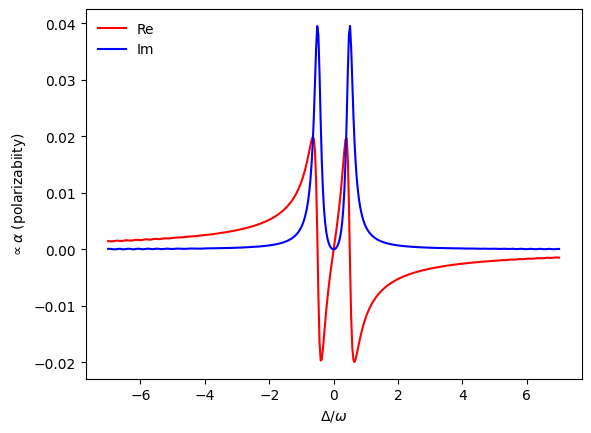

In [109]:
plt.xlabel(r'$\Delta/\omega$')
plt.ylabel(r'$\propto \alpha $ (polarizabiity)')
plt.plot(detuning_tab,-np.real(rhoeg_steady2),color='red',label=r'Re')
plt.plot(detuning_tab,-np.imag(rhoeg_steady2),color='blue',label=r'Im')
plt.legend(loc='upper left',fontsize=10,frameon=False)